In [2]:
import os
import requests
from datetime import datetime

def get_previous_month(year, month, n):
    """
    Retorna o ano e mês subtraindo n meses da data informada.
    Se n==0, retorna o mês atual.
    """
    month -= n
    while month <= 0:
        month += 12
        year -= 1
    return year, month

# Base da URL e padrão do nome do arquivo
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_usina_2_ho/"
file_template = "GERACAO_USINA-2_{year}_{month:02d}.parquet"

# Diretório de destino (referência relativa ao diretório base do projeto 'carga_liquida')
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.join(base_dir, "Data", "raw",'geracao por usina')
os.makedirs(dest_dir, exist_ok=True)

# Obter data atual e definir quantos meses queremos baixar (ex: 2 meses)
hoje = datetime.today()
meses_para_baixar = 2

# Loop para baixar o mês atual (i=0) e o mês anterior (i=1)
for i in range(0, meses_para_baixar):
    ano, mes = get_previous_month(hoje.year, hoje.month, i)
    file_name = file_template.format(year=ano, month=mes)
    url = base_url + file_name
    print(f"Tentando baixar: {url}")
    
    # Realiza o download
    response = requests.get(url, verify=False)
    if response.status_code == 200:
        # Monta o caminho completo para salvar o arquivo
        file_path = os.path.join(dest_dir, file_name)
        with open(file_path, 'wb') as f:
            f.write(response.content)
        print(f"Arquivo {file_name} baixado com sucesso em {file_path}.")
    else:
        print(f"Falha ao baixar {file_name}. Status: {response.status_code}")


Tentando baixar: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_usina_2_ho/GERACAO_USINA-2_2025_08.parquet


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo GERACAO_USINA-2_2025_08.parquet baixado com sucesso em c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\geracao por usina\GERACAO_USINA-2_2025_08.parquet.
Tentando baixar: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_usina_2_ho/GERACAO_USINA-2_2025_07.parquet


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo GERACAO_USINA-2_2025_07.parquet baixado com sucesso em c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\geracao por usina\GERACAO_USINA-2_2025_07.parquet.


In [3]:
import os
import pandas as pd

# Diretório contendo os arquivos .parquet (referência relativa ao diretório base do projeto 'carga_liquida')
# Usando o diretório do projeto como base, subindo um nível a partir do diretório atual
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
parquet_dir = os.path.join(base_dir, "Data", "raw", "geracao por usina")

# Lista para armazenar os DataFrames
dataframes = []

# Itera sobre os arquivos no diretório de geração
for arquivo in os.listdir(parquet_dir):
    if arquivo.endswith('.parquet'):
        caminho_completo = os.path.join(parquet_dir, arquivo)
        df = pd.read_parquet(caminho_completo)
        dataframes.append(df)

# Concatena todos os DataFrames em um único DataFrame
df_unido = pd.concat(dataframes, ignore_index=True)
geracao_usina = df_unido

# Caminho do arquivo de cadastro usando referência relativa
cadastro_file = os.path.join(base_dir, "Data", "raw", "cadastros", "cadastro.xlsx")

# Leitura do cadastro Excel
cadastro = pd.read_excel(cadastro_file)

# Filtra os dados de geração para usinas hidrelétricas
geracao_usina_hidro = geracao_usina.loc[geracao_usina['nom_tipousina'] == 'HIDROELÉTRICA']



In [4]:
data_inicio = "2022-01-01"
data_fim = "2025-09-30"


geracao_usina_hidro_filtrada = geracao_usina_hidro[(geracao_usina_hidro['din_instante'] >= data_inicio) & (geracao_usina_hidro['din_instante'] <= data_fim)]

In [5]:
geracao_usina_hidro_filtrada.head()

,din_instante,id_subsistema,nom_subsistema,id_estado,nom_estado,cod_modalidadeoperacao,nom_tipousina,nom_tipocombustivel,nom_usina,id_ons,ceg,val_geracao
0,2022-01-01,N,NORTE,AM,AMAZONAS,TIPO I,HIDROELÉTRICA,Hidráulica,Balbina,AMBA,UHE.PH.AM.000190-2.01,107.88100000
8,2022-01-01,N,NORTE,AP,AMAPA,TIPO I,HIDROELÉTRICA,Hidráulica,Coaracy Nunes,APCN,UHE.PH.AP.000783-8.01,72.17500000
9,2022-01-01,N,NORTE,AP,AMAPA,TIPO I,HIDROELÉTRICA,Hidráulica,Ferreira Gomes,APFGO,UHE.PH.AP.030385-2.01,159.95900000
10,2022-01-01,N,NORTE,AP,AMAPA,TIPO I,HIDROELÉTRICA,Hidráulica,Santo Antônio do Jari,APSAJ,UHE.PH.AP.026792-9.01,190.96800000
11,2022-01-01,N,NORTE,AP,AMAPA,TIPO I,HIDROELÉTRICA,Hidráulica,Cachoeira Caldeirão,APUCCA,UHE.PH.AP.031186-3.01,134.96700000


In [6]:
# Supondo que você já tenha os dataframes 'cadastro' e 'geracao_usina'

# Fazer o merge dos dois dataframes com base na coluna "nom_usina"
geracao_usina_hidro_filtrada = geracao_usina_hidro_filtrada.merge(cadastro, on='nom_usina', how='left')

# Separar os casos onde não há correspondência, ou seja, onde os valores da coluna "cadastro" são NaN
df_sem_correspondencia = geracao_usina_hidro_filtrada[geracao_usina_hidro_filtrada['Classificação'].isna()]

# Opcionalmente, você pode remover as linhas sem correspondência do dataframe original de geração de usina
df_geracao_com_correspondencia = geracao_usina_hidro_filtrada.dropna(subset=['Classificação'])

In [7]:
# Forçar 'val_geracao' a ser numérico, erros que não podem ser convertidos serão substituídos por NaN
df_geracao_com_correspondencia['val_geracao'] = pd.to_numeric(df_geracao_com_correspondencia['val_geracao'], errors='coerce')

C:\Users\joao.barbosa\AppData\Local\Temp\ipykernel_66280\2337550634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geracao_com_correspondencia['val_geracao'] = pd.to_numeric(df_geracao_com_correspondencia['val_geracao'], errors='coerce')


C:\Users\joao.barbosa\AppData\Local\Temp\ipykernel_66280\1699089414.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geracao_com_correspondencia['din_instante'] = pd.to_datetime(df_geracao_com_correspondencia['din_instante'])


<Figure size 1000x600 with 0 Axes>

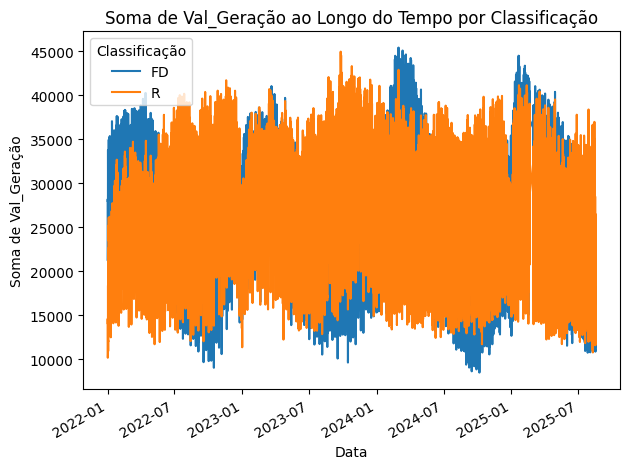

In [8]:
import matplotlib.pyplot as plt

# Converter 'din_instante' para datetime, caso não esteja
df_geracao_com_correspondencia['din_instante'] = pd.to_datetime(df_geracao_com_correspondencia['din_instante'])

# Agrupar por 'din_instante' e 'Classificação' e somar 'val_geracao'
df_grouped = df_geracao_com_correspondencia.groupby(['din_instante', 'Classificação'])['val_geracao'].sum().unstack()

# Plotar o gráfico de linhas para cada 'Classificação'
plt.figure(figsize=(10, 6))
df_grouped.plot(kind='line')

# Título e rótulos
plt.title('Soma de Val_Geração ao Longo do Tempo por Classificação')
plt.xlabel('Data')
plt.ylabel('Soma de Val_Geração')

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()


In [9]:
df_grouped = df_grouped.reset_index()

In [10]:
df_grouped['din_instante'] = pd.to_datetime(df_grouped['din_instante'])


In [11]:
# 1. Criar a coluna AnoMes como período mensal
df_grouped['AnoMes'] = df_grouped['din_instante'].dt.to_period('M')

# 2. Agrupar por AnoMes somando colunas FD e R
df_grouped_mensal = df_grouped.groupby('AnoMes')[['FD', 'R']].mean()

In [12]:
df_grouped_mensal = df_grouped_mensal.reset_index()

df_mensal_tidy = df_grouped_mensal.melt(
    id_vars='AnoMes',           # As colunas que permanecerão fixas
    var_name='Classificacao',   # Nome da coluna que vai conter "FD" ou "R"
    value_name='Valor'          # Nome da coluna que vai conter os valores
)

print(df_mensal_tidy)


     AnoMes Classificacao         Valor
0   2022-01            FD  31608.475341
1   2022-02            FD  32971.799384
2   2022-03            FD  32812.871690
3   2022-04            FD  32286.237033
4   2022-05            FD  27453.027042
..      ...           ...           ...
83  2025-04             R  22391.562608
84  2025-05             R  20180.318733
85  2025-06             R  20184.681689
86  2025-07             R  19653.604289
87  2025-08             R  19396.393809

[88 rows x 3 columns]


In [13]:
import os
output_dir = os.path.join("..", "Output", "geracao")
os.makedirs(output_dir, exist_ok=True)
df_mensal_tidy.to_excel(os.path.join(output_dir, "df_reservatorio_fiodagua.xlsx"))

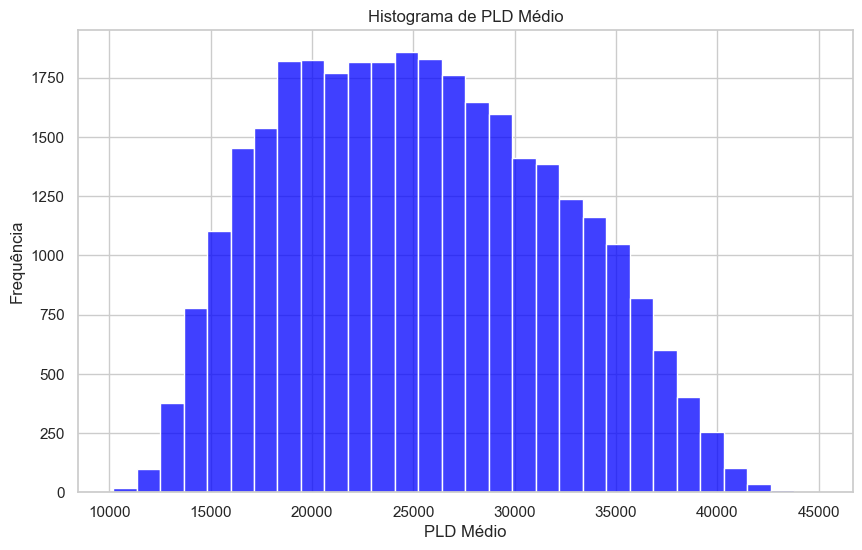

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Suponha que você tenha um DataFrame 'df' com a coluna 'pld_medio'

# Configurar o estilo dos plots
sns.set(style="whitegrid")

# Plotar o histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df_grouped, x='R', bins=30, kde=False, color='blue')

# Títulos e rótulos
plt.title('Histograma de PLD Médio')
plt.xlabel('PLD Médio')
plt.ylabel('Frequência')

# Exibir o gráfico
plt.show()


In [15]:
import os
import datetime
import requests
import pandas as pd


# Define o diretório de destino usando referência relativa ao root do projeto
import os

# Caminho relativo ao root do projeto (carga_liquida)
# Este notebook está em Scripts/, então subimos um nível e vamos para Data/raw/CMO
dest_dir = os.path.abspath(os.path.join("..", "Data", "raw", "CMO"))

# Cria o diretório se ele não existir
os.makedirs(dest_dir, exist_ok=True)

# Obtém o ano corrente
ano_corrente = datetime.datetime.now().year

# Monta a URL com o ano corrente
url = f"https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/cmo_tm/CMO_SEMIHORARIO_{ano_corrente}.parquet"
print("Baixando arquivo:", url)

# Define o caminho completo para salvar o arquivo
nome_arquivo = f"CMO_SEMIHORARIO_{ano_corrente}.parquet"
dest_file = os.path.join(dest_dir, nome_arquivo)

# Realiza o download do arquivo
response = requests.get(url, stream=True,verify=False)
if response.status_code == 200:
    with open(dest_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Arquivo baixado com sucesso em: {dest_file}")
else:
    print("Falha no download. Código de status:", response.status_code)

# Opcional: Carrega o arquivo baixado em um DataFrame do Pandas
try:
    df = pd.read_parquet(dest_file)
    print("Exibindo as primeiras linhas do DataFrame:")
    print(df.head())
except Exception as e:
    print("Erro ao ler o arquivo Parquet:", e)


Baixando arquivo: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/cmo_tm/CMO_SEMIHORARIO_2025.parquet


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo baixado com sucesso em: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\CMO\CMO_SEMIHORARIO_2025.parquet
Exibindo as primeiras linhas do DataFrame:
  id_subsistema nom_subsistema        din_instante  val_cmo
0            NE       NORDESTE 2025-01-01 00:00:00    12.32
1             N          NORTE 2025-01-01 00:00:00    12.34
2            SE        SUDESTE 2025-01-01 00:00:00    12.34
3             S            SUL 2025-01-01 00:00:00    12.34
4            NE       NORDESTE 2025-01-01 00:30:00    12.08


In [16]:
# Lista para armazenar os DataFrames
dataframes = []

# Itera sobre os arquivos no diretório
for arquivo in os.listdir(dest_dir):
    if arquivo.endswith('.parquet'):
        caminho_completo = os.path.join(dest_dir, arquivo)
        df = pd.read_parquet(caminho_completo)
        dataframes.append(df)

# Concatena todos os DataFrames
df_unido_cmo = pd.concat(dataframes, ignore_index=True)

In [17]:
df_unido_cmo_sudeste = df_unido_cmo.loc[df_unido_cmo['nom_subsistema']=='SUDESTE']

In [18]:
# Exemplo de Left Join
df_merged = pd.merge(
    df_grouped,
    df_unido_cmo_sudeste,
    on='din_instante',
    how='left',           # Tipo de junção: 'inner', 'left', 'right', 'outer'
    suffixes=('_grouped', '_sudeste')  # Sufixos para colunas com nomes iguais
)

In [19]:
# Exemplo de conversão para float
df_merged['R'] = df_merged['R'].astype(float)
df_merged['val_cmo'] = df_merged['val_cmo'].astype(float)

# Remover linhas com valores faltantes
df_clean = df_merged.dropna(subset=['R', 'val_cmo'])

df_clean = df_clean.loc[df_clean['R']>0]
df_clean = df_clean.loc[df_clean['val_cmo']>0]
df_clean = df_clean[(df_clean['din_instante'] >= '2024-01-1') & (df_clean['din_instante'] <= '2024-12-31')]

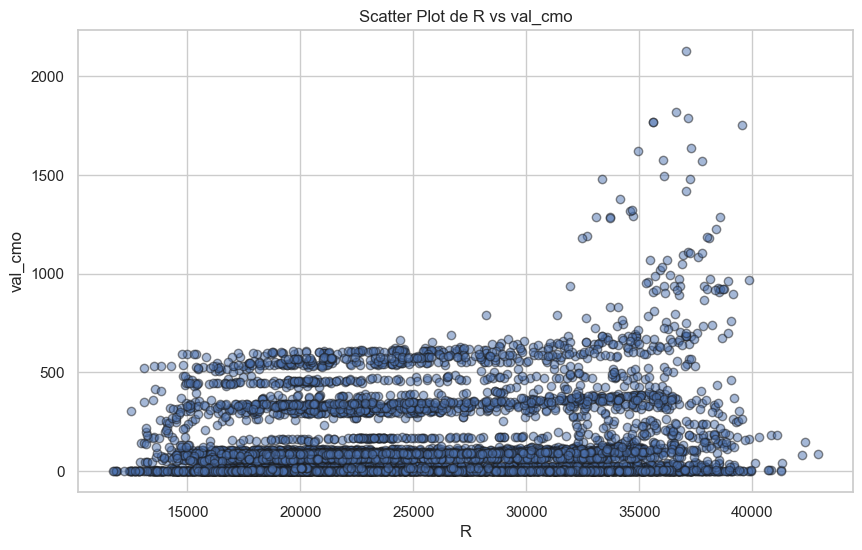

In [20]:
import matplotlib.pyplot as plt

# Criar uma figura e um eixo
plt.figure(figsize=(10, 6))

# Plotar os dados
plt.scatter(df_clean['R'], df_clean['val_cmo'], alpha=0.5, edgecolor='k')

# Adicionar títulos e rótulos
plt.title('Scatter Plot de R vs val_cmo')
plt.xlabel('R')
plt.ylabel('val_cmo')

# Mostrar o gráfico
plt.grid(True)
plt.show()


In [21]:
# Fazer o merge dos dois dataframes com base na coluna "nom_usina"
geracao_usina_filtrada = geracao_usina.merge(cadastro, on='nom_usina', how='left')

In [22]:
geracao_usina_filtrada['nom_tipousina'] = geracao_usina_filtrada.apply(
    lambda row: f"{row['nom_tipousina']} - {row['Classificação']}" if pd.notna(row['Classificação']) else row['nom_tipousina'],
    axis=1
)

In [23]:
import pandas as pd


# Verificando se os valores de 'val_geracao' estão em formato numérico e forçando a conversão, se necessário
geracao_usina_filtrada['val_geracao'] = pd.to_numeric(geracao_usina_filtrada['val_geracao'], errors='coerce')

# Convertendo a coluna 'din_instante' para datetime, caso não esteja já no formato correto
geracao_usina_filtrada['din_instante'] = pd.to_datetime(geracao_usina_filtrada['din_instante'])

# Agrupando por 'din_instante' e 'nom_tipousina', somando os valores de 'val_geracao'
resultado_agrupado = geracao_usina_filtrada.groupby(['din_instante', 'nom_tipousina']).agg({'val_geracao': 'sum'}).reset_index()



In [24]:
# Realizando a operação de pivot, onde 'din_instante' será o índice e 'nom_tipousina' se tornarão colunas
resultado_pivot = resultado_agrupado.pivot(index='din_instante', columns='nom_tipousina', values='val_geracao')


In [25]:
# Redefinir o índice se 'din_instante' for parte do índice
if 'din_instante' not in resultado_pivot.columns:
    resultado_pivot = resultado_pivot.reset_index()

    # Verificar se 'din_instante' agora está nas colunas
    print("\nApós redefinir o índice:")
    print(resultado_pivot.columns)
else:
    print("\n'din_instante' já está presente como uma coluna.")



Após redefinir o índice:
Index(['din_instante', 'EOLIELÉTRICA', 'FOTOVOLTAICA', 'HIDROELÉTRICA',
       'HIDROELÉTRICA - FD', 'HIDROELÉTRICA - R', 'NUCLEAR', 'TÉRMICA',
       'TÉRMICA - FD'],
      dtype='object', name='nom_tipousina')


In [ ]:
resultado_pivot = resultado_pivot[(resultado_pivot['din_instante'] >= data_inicio) & (resultado_pivot['din_instante'] <= data_fim)]

In [27]:
import os
import requests
from datetime import datetime

# Diretório absoluto para salvar os arquivos
download_dir = r"C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica"

# Garante que o diretório existe antes de tentar salvar arquivos
os.makedirs(download_dir, exist_ok=True)

# Função para calcular o mês anterior
def get_previous_month(year, month):
    if month == 1:
        return year - 1, 12
    else:
        return year, month - 1

# Obter data atual
today = datetime.today()
year_atual = today.year
month_atual = today.month

# Listar os dois meses (mês atual e o anterior)
meses = [(year_atual, month_atual)]
ano_prev, mes_prev = get_previous_month(year_atual, month_atual)
meses.append((ano_prev, mes_prev))

# URL base
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_termica_despacho_2_ho"

# Loop para baixar os arquivos dos dois meses
for ano, mes in meses:
    mes_str = str(mes).zfill(2)  # garantir dois dígitos
    nome_arquivo = f"GERACAO_TERMICA_DESPACHO-2_{ano}_{mes_str}.parquet"
    url = f"{base_url}/{nome_arquivo}"
    
    print(f"Baixando arquivo: {url}")
    
    try:
        resposta = requests.get(url,verify=False)
        resposta.raise_for_status()  # levanta exceção para códigos de erro HTTP
    except requests.exceptions.RequestException as e:
        print(f"Erro ao baixar {nome_arquivo}: {e}")
        continue
    
    # Caminho completo para salvar o arquivo
    caminho_arquivo = os.path.join(download_dir, nome_arquivo)
    
    try:
        with open(caminho_arquivo, 'wb') as f:
            f.write(resposta.content)
        print(f"Arquivo salvo em: {caminho_arquivo}")
    except Exception as e:
        print(f"Erro ao salvar {nome_arquivo}: {e}")


Baixando arquivo: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_termica_despacho_2_ho/GERACAO_TERMICA_DESPACHO-2_2025_08.parquet


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2025_08.parquet
Baixando arquivo: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/geracao_termica_despacho_2_ho/GERACAO_TERMICA_DESPACHO-2_2025_07.parquet


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2025_07.parquet


In [28]:
import os
import glob
import pandas as pd

# Diretório onde estão os arquivos .parquet
#directory = r"C:\Users\joao.barbosa\Codigos\despacho_termo\Data\Dados Brutos"

# Lista todos os arquivos .parquet no diretório
arquivos = glob.glob(os.path.join(download_dir, "*.parquet"))

# Lista para armazenar os DataFrames
lista_dfs = []

# Lê cada arquivo .parquet e adiciona o DataFrame à lista
for arquivo in arquivos:
    print(f"Lendo: {arquivo}")
    try:
        df = pd.read_parquet(arquivo)
        lista_dfs.append(df)
    except Exception as e:
        print(f"Erro ao ler o arquivo {arquivo}: {e}")

# Verifica se foram encontrados arquivos e concatena os DataFrames
if lista_dfs:
    df_concatenado = pd.concat(lista_dfs, ignore_index=True)
    print("Todos os arquivos foram concatenados com sucesso!")
else:
    print("Nenhum arquivo .parquet foi encontrado no diretório.")


Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_01.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_02.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_03.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_04.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_05.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_06.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Data\raw\termoeletrica\GERACAO_TERMICA_DESPACHO-2_2022_07.parquet
Lendo: C:\Users\joao.barbosa\Desktop\Códi

In [29]:
# Identifica as colunas que começam com 'val_prog'
cols_to_drop = [col for col in df_concatenado.columns if col.startswith('val_prog')]

# Remove as colunas do DataFrame
df_concatenado = df_concatenado.drop(columns=cols_to_drop)


In [30]:
# 1. Remover as colunas indesejadas
colunas_excluir = [
    "val_verifordemmerito", 
    "val_verifinflexembutmerito",
    "val_verifinflexpura",
    "val_fdexp",
    "val_atendsatisfatoriorpo",
    "val_verifconstrainedoff", 
    "tip_restricaoeletrica",
    "nom_tipopatamar",
    "nom_subsistema",
    "cod_usinaplanejamento"
]
df = df_concatenado.drop(columns=colunas_excluir, errors='ignore')

In [31]:
import pandas as pd

# Lista das colunas que serão convertidas e somadas
cols_sum = [
    'val_verifgeracao',
    'val_verifordemdemeritoacimadainflex',
    'val_verifinflexibilidade',
    'val_verifrazaoeletrica',
    'val_verifgarantiaenergetica',
    'val_verifgfom',
    'val_verifreposicaoperdas',
    'val_verifexportacao',
    'val_verifreservapotencia',
    'val_verifgsub',
    'val_verifunitcommitment'
]

# Converte as colunas especificadas para numérico, tratando erros como NaN
for col in cols_sum:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Agora agrupa os dados pela coluna 'din_instante' e realiza a soma
df_agrupado = df.groupby('din_instante')[cols_sum].sum().reset_index()


In [33]:
import matplotlib.pyplot as plt
import os

# Caminho para salvar os gráficos
output_dir = r'C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Output\charts'
os.makedirs(output_dir, exist_ok=True)

# Colunas para o gráfico stacked
colunas_stacked = [
    'val_verifordemdemeritoacimadainflex',
    'val_verifinflexibilidade',
    'val_verifrazaoeletrica',
    'val_verifgarantiaenergetica',
    'val_verifgfom',
    'val_verifreposicaoperdas',
    'val_verifexportacao',
    'val_verifreservapotencia',
    'val_verifgsub',
    'val_verifunitcommitment'
]

# Garantir que as colunas existem no DataFrame
colunas_stacked = [col for col in colunas_stacked if col in df_agrupado.columns]

# Extrair os 4 últimos dias disponíveis
df_agrupado['data'] = pd.to_datetime(df_agrupado['din_instante']).dt.date
ultimos_dias = sorted(df_agrupado['data'].unique())[-4:]

for dia in ultimos_dias:
    # Selecionar os dados do dia
    df_dia = df_agrupado[df_agrupado['data'] == dia].copy()
    if df_dia.empty:
        continue

    # Preparar dados para o gráfico
    df_dia_plot = df_dia.set_index('din_instante')[colunas_stacked]

    # Plotar gráfico stacked
    ax = df_dia_plot.plot(
        kind='bar',
        stacked=True,
        figsize=(16, 8),
        colormap='tab20'
    )
    plt.title(f'Componentes de Geração para o dia {dia}')
    plt.xlabel('Horário')
    plt.ylabel('MW')
    plt.xticks(rotation=45)
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.tight_layout()

    # Salvar o gráfico
    nome_arquivo = f'componentes_geracao_{dia}.png'
    caminho_arquivo = os.path.join(output_dir, nome_arquivo)
    plt.savefig(caminho_arquivo)
    plt.close()

In [34]:
# 3. Selecionar Apenas as Colunas Necessárias para a União
df_to_merge = df_agrupado[['din_instante', 'val_verifordemdemeritoacimadainflex','val_verifunitcommitment','val_verifexportacao']].copy()


In [35]:
# 4. Realizar a União dos DataFrames
tipo_juncao = 'left'  # 'left', 'inner', 'right', 'outer'
df_merged = pd.merge(
    resultado_pivot,
    df_to_merge,
    on='din_instante',
    how=tipo_juncao,
    suffixes=('_resultado', '_agrupado')
)


# 6. Tratar Valores Faltantes, se Necessário
# Exemplo: Preencher com a média
mean_val = df_merged['val_verifordemdemeritoacimadainflex'].mean()
df_merged['val_verifordemdemeritoacimadainflex'].fillna(mean_val, inplace=True)

C:\Users\joao.barbosa\AppData\Local\Temp\ipykernel_66280\53414622.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['val_verifordemdemeritoacimadainflex'].fillna(mean_val, inplace=True)


In [42]:
# Gráfico temporal da soma 'val_verifordemdemeritoacimadainflex + val_verifunitcommitment' com média móvel de 24 horas
import matplotlib.pyplot as plt
import os

# Definir datas de início e fim da análise
data_inicio_analise = pd.Timestamp('2025-01-01')
data_fim_analise = pd.to_datetime(df_merged['din_instante']).max()  # Última data disponível

# Filtrar o DataFrame para o período desejado
df_analise = df_merged[
    (pd.to_datetime(df_merged['din_instante']) >= data_inicio_analise) &
    (pd.to_datetime(df_merged['din_instante']) <= data_fim_analise)
].copy()

# Calcular a soma das duas colunas
df_analise['soma_valores'] = (
    df_analise['val_verifordemdemeritoacimadainflex'] + df_analise['val_verifunitcommitment']
)

# Calcular a média móvel de 24 períodos (horas) da soma
df_analise = df_analise.sort_values('din_instante')
df_analise['media_movel_24h'] = df_analise['soma_valores'].rolling(window=24, min_periods=1).mean()

# Gráfico
plt.figure(figsize=(14,6))
plt.plot(pd.to_datetime(df_analise['din_instante']), df_analise['soma_valores'], label='Soma Original', alpha=0.5)
plt.plot(pd.to_datetime(df_analise['din_instante']), df_analise['media_movel_24h'], label='Média Móvel 24h', color='red', linewidth=2)
plt.title('Evolução temporal da soma val_verifordemdemeritoacimadainflex + val_verifunitcommitment (2024 até última data disponível)')
plt.xlabel('Data')
plt.ylabel('Soma dos valores')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Salvar a imagem no diretório especificado
output_dir = r'C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Output\charts'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'grafico_soma_valores_e_media_movel_24h.png')
plt.savefig(output_path)
plt.close()

In [40]:
df_merged['carga_liquida'] = df_merged['HIDROELÉTRICA - R']+df_merged['val_verifordemdemeritoacimadainflex']+df_merged['val_verifunitcommitment']

In [41]:
# Convertendo a coluna 'din_instante' para datetime, caso não esteja já no formato correto
df_merged['din_instante'] = pd.to_datetime(df_merged['din_instante'])

In [43]:
# Exemplo de Left Join
df_merged_liquido = pd.merge(
    df_merged,
    df_unido_cmo_sudeste,
    on='din_instante',
    how='left',           # Tipo de junção: 'inner', 'left', 'right', 'outer'
    suffixes=('_grouped', '_sudeste')  # Sufixos para colunas com nomes iguais
)

In [44]:
# Exemplo de conversão para float
df_merged_liquido['carga_liquida'] = df_merged_liquido['carga_liquida'].astype(float)
df_merged_liquido['val_cmo'] = df_merged_liquido['val_cmo'].astype(float)

# Remover linhas com valores faltantes
df_clean = df_merged_liquido.dropna(subset=['carga_liquida', 'val_cmo'])

In [45]:
df_clean = df_clean[(df_clean['din_instante'] >= data_inicio) & (df_clean['din_instante'] <= data_fim)]

In [268]:
#df_clean = df_clean.loc[df_clean['carga_liquida']>0]
#df_clean = df_clean.loc[df_clean['val_cmo']>=0]

'din_instante' já está presente como uma coluna.


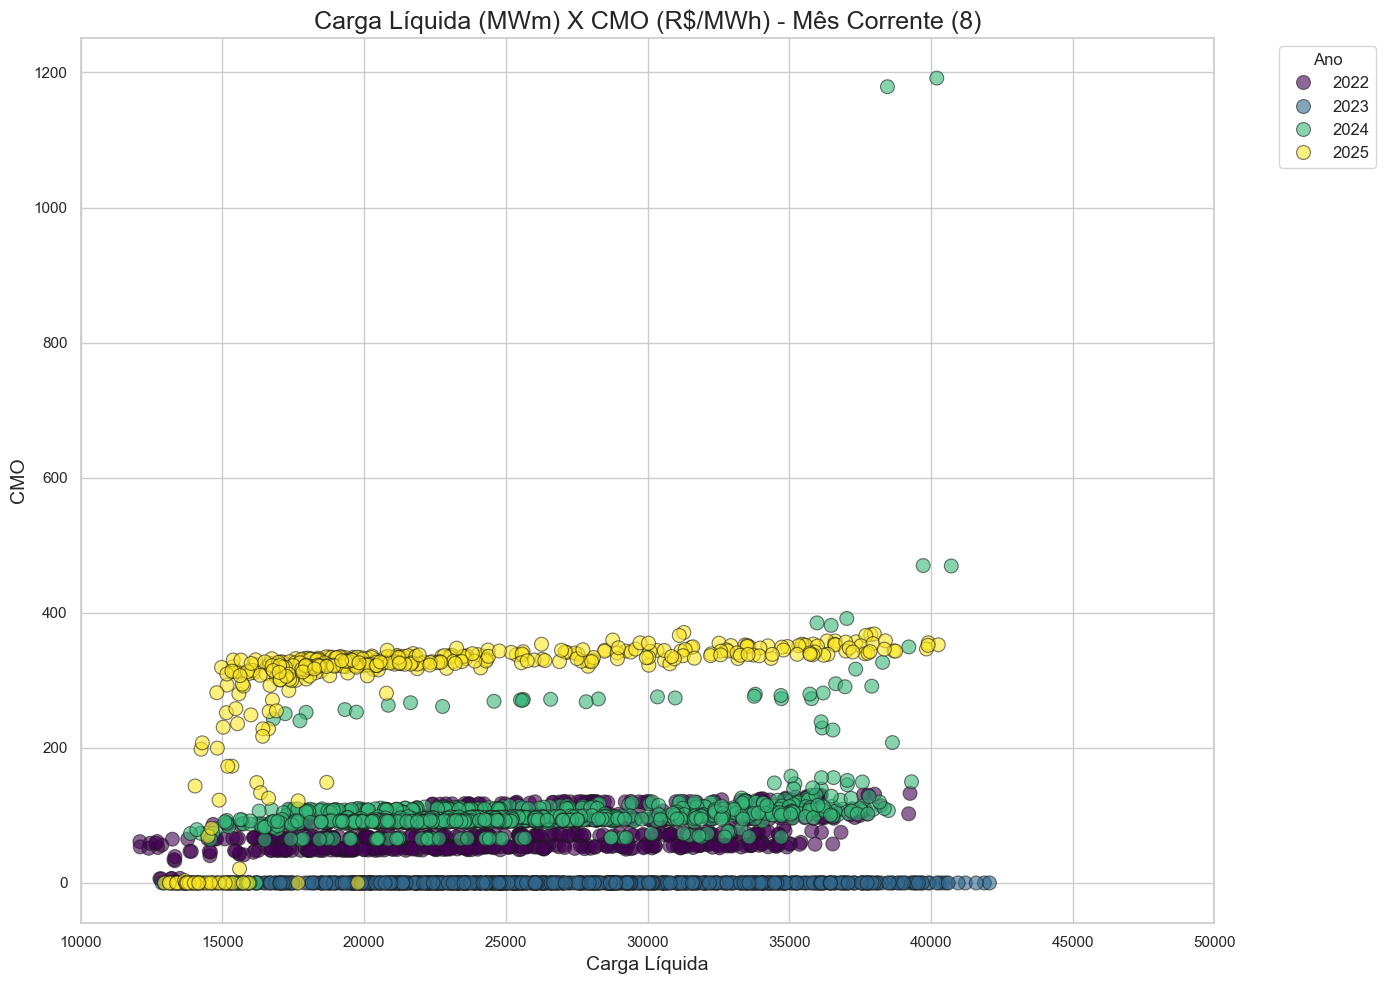

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Verificar se 'din_instante' é uma coluna ou índice
if 'din_instante' not in df_clean.columns:
    df_clean = df_clean.reset_index()
    print("'din_instante' foi movido do índice para as colunas.")
else:
    print("'din_instante' já está presente como uma coluna.")

# 2. Converter 'din_instante' para datetime
df_clean['din_instante'] = pd.to_datetime(df_clean['din_instante'], errors='coerce')

# 3. Extrair o ano e o mês
df_clean['year'] = df_clean['din_instante'].dt.year
df_clean['month'] = df_clean['din_instante'].dt.month

# 4. Remover linhas com valores faltantes em 'year', 'month', 'carga_liquida', ou 'val_cmo'
df_clean_plot = df_clean.dropna(subset=['year', 'month', 'carga_liquida', 'val_cmo'])

# 5. Converter 'year' e 'month' para inteiro
df_clean_plot['year'] = df_clean_plot['year'].astype(int)
df_clean_plot['month'] = df_clean_plot['month'].astype(int)

# 6. Filtrar para apenas o mês corrente
mes_corrente = datetime.now().month
df_mes_corrente = df_clean_plot[df_clean_plot['month'] == mes_corrente]

# 7. Plotar o scatter plot com Seaborn apenas para o mês corrente
sns.set(style="whitegrid")

plt.figure(figsize=(14, 10))
scatter = sns.scatterplot(
    data=df_mes_corrente,
    x='carga_liquida',
    y='val_cmo',
    hue='year',
    palette='viridis',
    alpha=0.6,
    edgecolor='k',
    s=100  # Tamanho dos pontos
)

# Definir os limites do eixo x entre 10000 e 50000
plt.xlim(10000, 50000)

# Personalizar títulos e rótulos
plt.title(f'Carga Líquida (MWm) X CMO (R$/MWh) - Mês Corrente ({mes_corrente})', fontsize=18)
plt.xlabel('Carga Líquida', fontsize=14)
plt.ylabel('CMO', fontsize=14)

# Ajustar a legenda
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Mostrar o gráfico
plt.tight_layout()
plt.show()


'din_instante' já está presente como uma coluna.


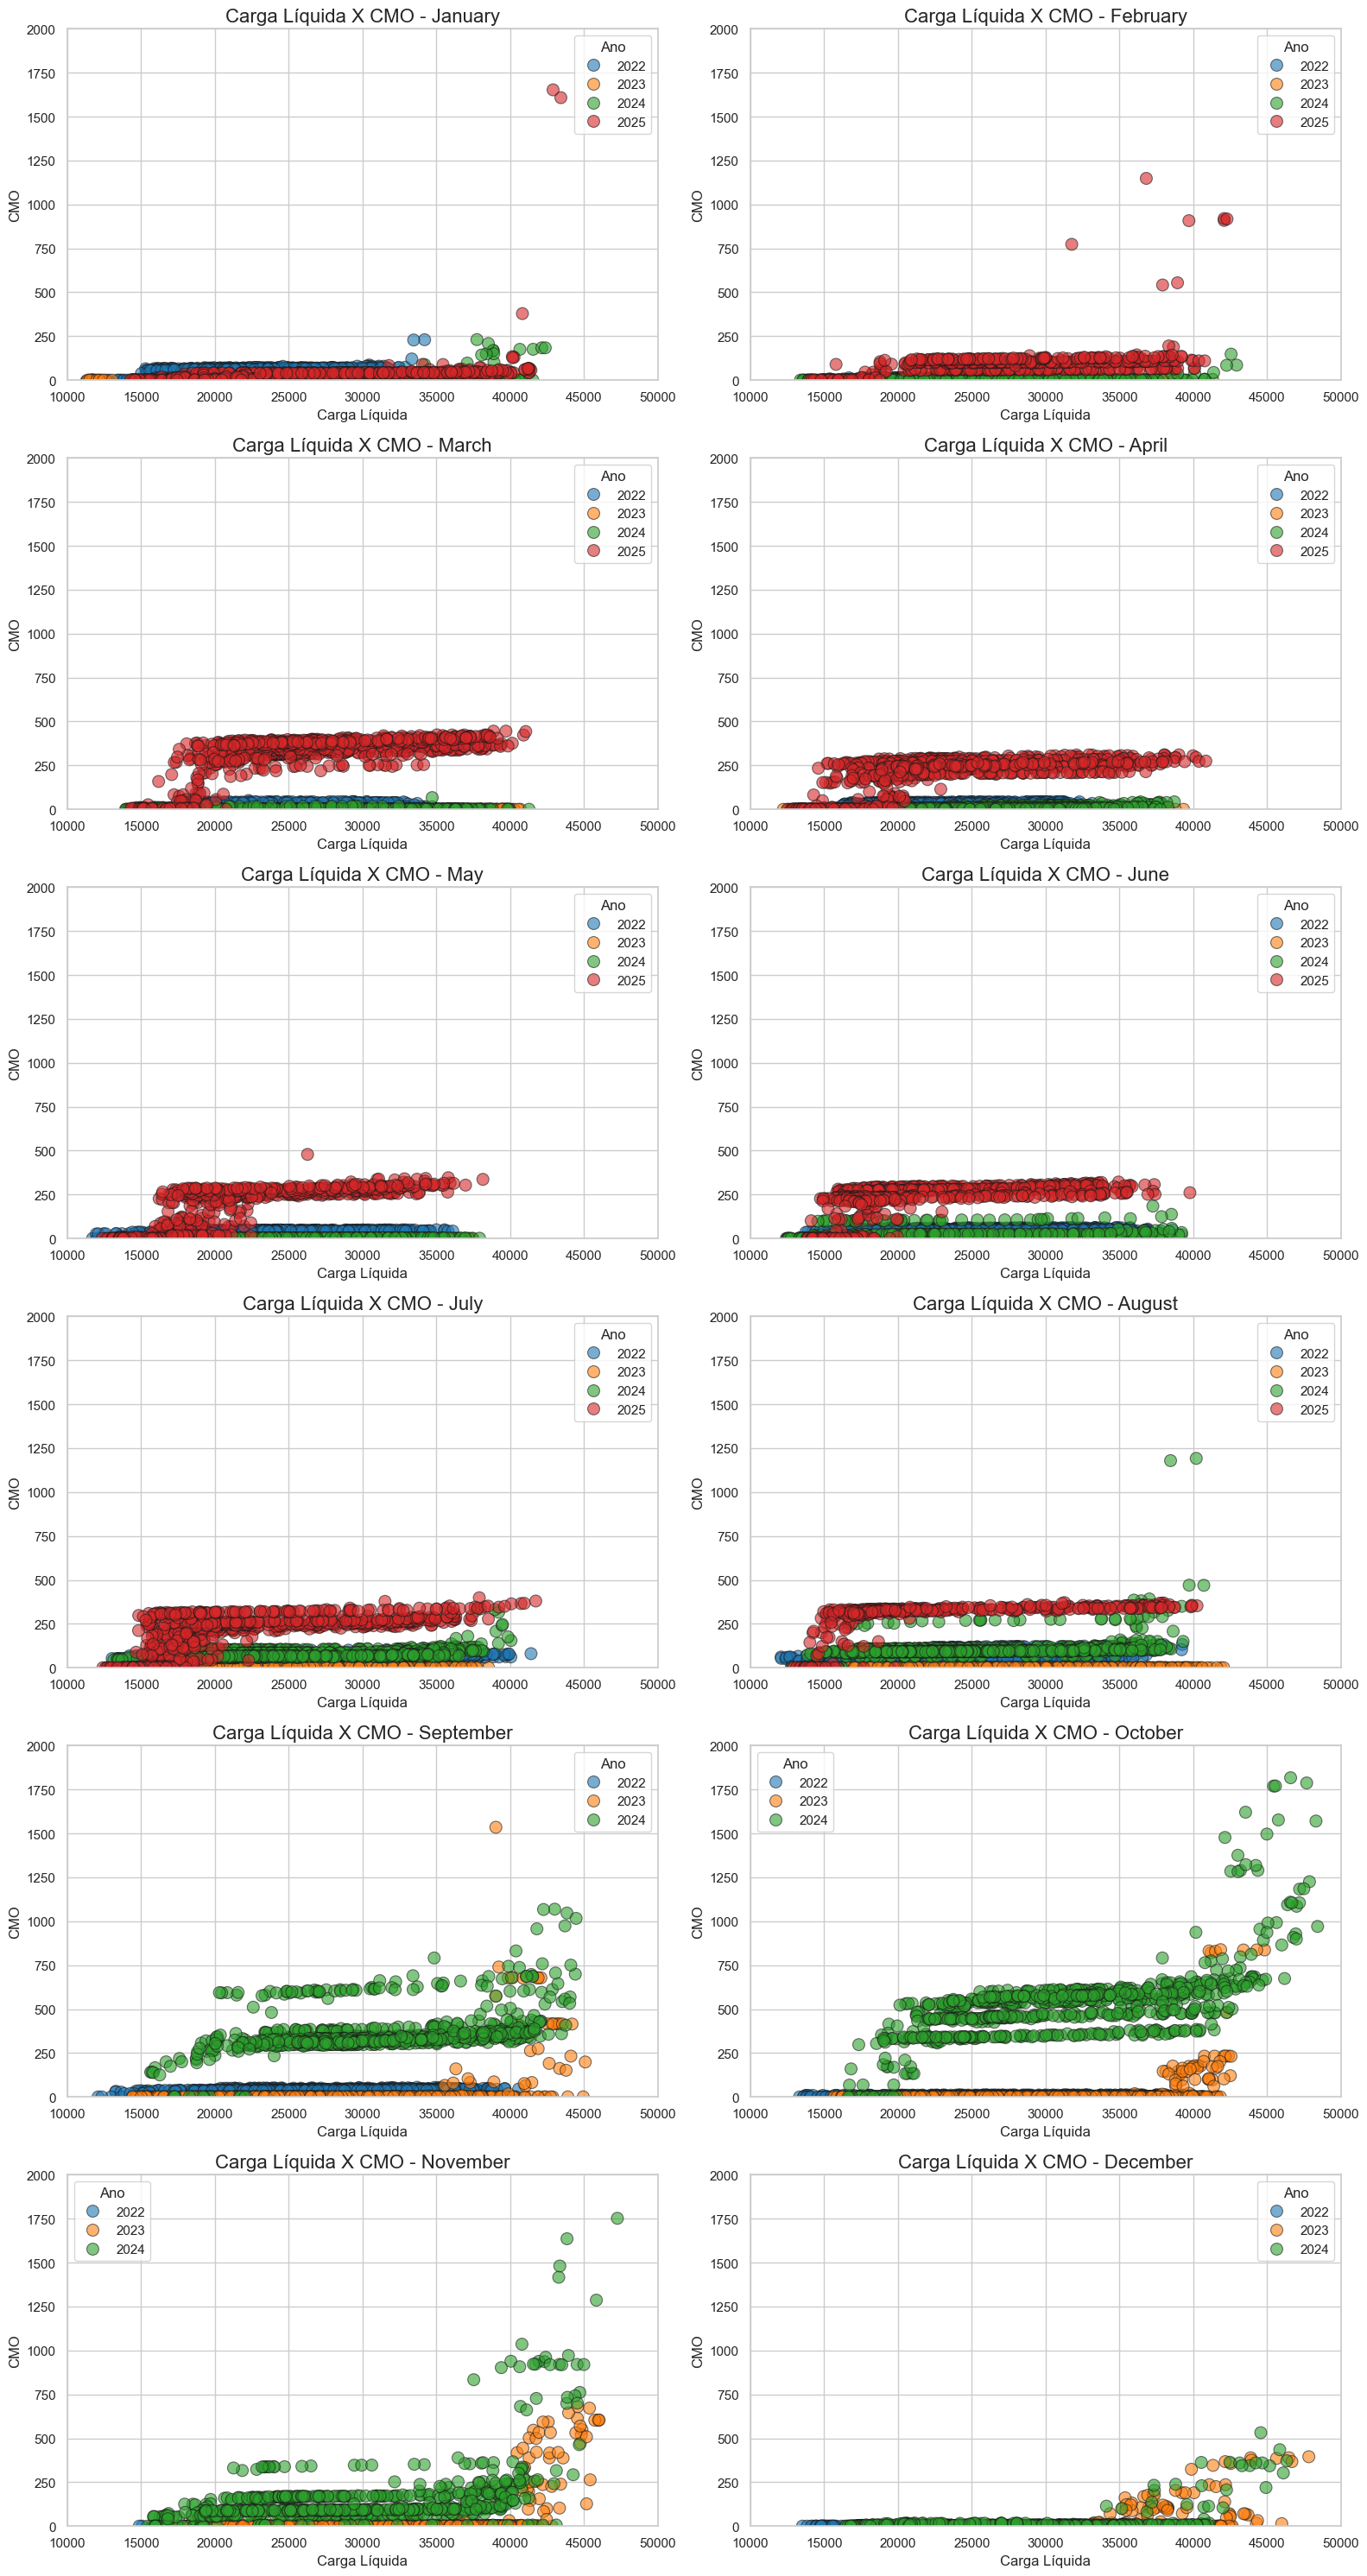

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que 'df_clean' já esteja definido anteriormente
# Exemplo:
# df_clean = pd.read_csv('seu_arquivo.csv')

# 1. Verificar se 'din_instante' é uma coluna ou índice
if 'din_instante' not in df_clean.columns:
    df_clean = df_clean.reset_index()
    print("'din_instante' foi movido do índice para as colunas.")
else:
    print("'din_instante' já está presente como uma coluna.")

# 2. Converter 'din_instante' para datetime
df_clean['din_instante'] = pd.to_datetime(df_clean['din_instante'], errors='coerce')

# 3. Extrair o ano e o mês
df_clean['year'] = df_clean['din_instante'].dt.year
df_clean['month'] = df_clean['din_instante'].dt.month
df_clean['month_name'] = df_clean['din_instante'].dt.strftime('%B')  # Nome do mês para melhor legibilidade

# 4. Remover linhas com valores faltantes em 'year', 'carga_liquida', ou 'val_cmo'
df_clean_plot = df_clean.dropna(subset=['year', 'carga_liquida', 'val_cmo'])

# 5. Converter 'year' e 'month' para inteiro
df_clean_plot['year'] = df_clean_plot['year'].astype(int)
df_clean_plot['month'] = df_clean_plot['month'].astype(int)

# Lista de meses que você deseja visualizar
meses_selecionados = [1,2,3,4,5,6,7, 8, 9, 10,11,12]  # Substitua pelos meses de interesse, onde 1 = Janeiro, 2 = Fevereiro, etc.

# 6. Plotar scatter plots para os meses selecionados em uma grade 2xN
sns.set(style="whitegrid")

# Configurações para grade
ncols = 2
nrows = (len(meses_selecionados) + 1) // ncols  # Calcula o número de linhas necessárias
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()  # Achatar os eixos para fácil indexação

# Loop para plotar cada mês selecionado
for i, mes in enumerate(meses_selecionados):
    # Filtrar os dados para o mês específico
    df_mes = df_clean_plot[df_clean_plot['month'] == mes]
    
    # Plotar o scatter plot com 'hue' baseado no ano para diferenciar as cores
    sns.scatterplot(
        data=df_mes,
        x='carga_liquida',
        y='val_cmo',
        hue='year',  # Usar o ano para diferenciar as cores
        palette="tab10",  # Escolher uma paleta que suporte múltiplos anos
        alpha=0.6,
        edgecolor='k',
        s=100,
        ax=axes[i]  # Colocar cada plot em uma posição específica
    )

    # Configurar limites e títulos
    axes[i].set_xlim(10000, 50000)
    axes[i].set_ylim(0, 2000)
    axes[i].set_title(f'Carga Líquida X CMO - {df_mes["month_name"].iloc[0]}', fontsize=16)
    axes[i].set_xlabel('Carga Líquida', fontsize=12)
    axes[i].set_ylabel('CMO', fontsize=12)

    # Ajustar a legenda para cada plot
    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles=handles, labels=labels, title='Ano')

# Remover eixos vazios, caso haja
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar o layout para evitar sobreposição
plt.tight_layout()
plt.savefig("grafico_alta_definicao.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import os

# --- Função para plotar e salvar o gráfico para um dia específico ---
def plotar_e_salvar_grafico(df, dia, output_dir):
    # Filtra para o dia escolhido (ignora hora/minuto/segundo)
    df_dia = df[df['din_instante'].dt.strftime('%Y-%m-%d') == dia]

    # --- Seleção das colunas de interesse ---
    colunas_usinas = [
        'EOLIELÉTRICA', 'FOTOVOLTAICA', 'HIDROELÉTRICA', 'HIDROELÉTRICA - FD', 'HIDROELÉTRICA - R',
        'NUCLEAR', 'TÉRMICA', 'TÉRMICA - FD', 'TÉRMICA-FD'
    ]
    colunas_presentes = [col for col in colunas_usinas if col in df_dia.columns]

    # --- Plot Stacked + carga_liquida + (linha da soma das duas verificações) ---
    if not df_dia.empty and colunas_presentes:
        df_dia = df_dia.sort_values('din_instante')
        x = df_dia['din_instante']
        y = [df_dia[col].fillna(0).values for col in colunas_presentes]

        plt.figure(figsize=(16, 8))
        # Stacked area plot das usinas
        plt.stackplot(x, y, labels=colunas_presentes, alpha=0.7)

        # Linha de carga_liquida
        if 'carga_liquida' in df_dia.columns:
            plt.plot(x, df_dia['carga_liquida'], color='black', linewidth=2, label='Carga Líquida')

        # Linha da soma das duas verificações
        has_ordem = 'val_verifordemdemeritoacimadainflex' in df_dia.columns
        has_unit = 'val_verifunitcommitment' in df_dia.columns
        if has_ordem or has_unit:
            v1 = df_dia['val_verifordemdemeritoacimadainflex'].fillna(0) if has_ordem else 0
            v2 = df_dia['val_verifunitcommitment'].fillna(0) if has_unit else 0
            soma_verificacoes = v1 + v2
            plt.plot(x, soma_verificacoes, color='red', linewidth=2, linestyle='--', label='Soma Verif. Ordem de Mérito + Unit Commitment')

        plt.title(f'Geração por Tipo de Usina, Carga Líquida e Soma das Verificações - {dia}')
        plt.xlabel('Hora')
        plt.ylabel('Geração (MW)')
        plt.legend(loc='upper left')
        plt.tight_layout()

        # Salvar o gráfico
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        nome_arquivo = f"grafico_{dia}.png"
        caminho_arquivo = os.path.join(output_dir, nome_arquivo)
        plt.savefig(caminho_arquivo, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        print(f"Não há dados para o dia {dia} ou colunas de usinas não encontradas.")

# --- Garante que 'din_instante' está em datetime ---
df_clean_plot['din_instante'] = pd.to_datetime(df_clean_plot['din_instante'], errors='coerce')

# --- Seleciona os últimos 4 dias disponíveis ---
df_validos = df_clean_plot.dropna(subset=['din_instante'])
ultimos_dias = (
    df_validos['din_instante']
    .dt.strftime('%Y-%m-%d')
    .drop_duplicates()
    .sort_values(ascending=False)
    .head(4)
    .tolist()
)

output_dir = r"C:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\carga_liquida\Output\charts"

for dia in ultimos_dias:
    plotar_e_salvar_grafico(df_clean_plot, dia, output_dir)

: 